<a href="https://colab.research.google.com/github/Samir0223/Attention_U_Net-/blob/main/UNet_ROSE1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# U-Net Pipeline — ROSE-1 Dataset

Simple Attention U-Net for retinal vessel segmentation with K-Fold cross-validation.

| | |
|---|---|
| **Model** | U-Net with Attention Gates |
| **Dataset** | ROSE-1 (SVC / DVC / SVC_DVC) |
| **GT types** | `gt`, `thick_gt`, `thin_gt` |
| **Loss** | BCE |
| **CV** | 10-Fold (30 train images) |
| **Metrics** | Dice, Jaccard, Sensitivity, Specificity, AUC |

## 1. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import torch
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {"GPU — " + torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')


Mounted at /content/drive
PyTorch : 2.10.0+cu128
Device  : GPU — Tesla T4


In [ ]:
import subprocess
subprocess.run(['pip', 'install', '-q', 'seaborn'], check=True)


CompletedProcess(args=['pip', 'install', '-q', 'seaborn'], returncode=0)

## 2. Configuration

In [ ]:
import os

# === Edit these ===
BASE_DIR    = '/content/drive/MyDrive/ROSE-1'
CATEGORY    = 'SVC_DVC'   # 'SVC' | 'DVC' | 'SVC_DVC'
GT_TYPE     = 'gt'        # 'gt'  | 'thick_gt' | 'thin_gt'
IMG_SIZE    = 304          # resize target (power of 2 friendly for U-Net)
BATCH_SIZE  = 4
K_FOLDS     = 5 # Instead of 10 folds
NUM_EPOCHS  = 25 # Instead of 50
LR          = 1e-3 # 3 instead of 4
SAVE_DIR    = f'/content/drive/MyDrive/UNet_ROSE1/{CATEGORY}_{GT_TYPE}'
# ==================

os.makedirs(SAVE_DIR, exist_ok=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Sanity-check paths
for split in ['train', 'test']:
    for sub in ['img', GT_TYPE]:
        p = os.path.join(BASE_DIR, CATEGORY, split, sub)
        print(f'  {split}/{sub}: {"OK" if os.path.isdir(p) else "MISSING"}')


  train/img: OK
  train/gt: OK
  test/img: OK
  test/gt: OK


## 3. Dataset

In [ ]:
import os, random
import numpy as np
from PIL import Image
import torch
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader


class ROSE1Dataset(Dataset):
    def __init__(self, base_dir, category, split,
                 gt_type='gt', indices=None, augment=False, img_size=304):
        img_dir  = os.path.join(base_dir, category, split, 'img')
        gt_dir   = os.path.join(base_dir, category, split, gt_type)
        all_imgs  = sorted(os.listdir(img_dir))
        all_masks = sorted(os.listdir(gt_dir))

        if indices is not None:
            all_imgs  = [all_imgs[i]  for i in indices]
            all_masks = [all_masks[i] for i in indices]

        self.samples  = [(os.path.join(img_dir, i), os.path.join(gt_dir, m))
                         for i, m in zip(all_imgs, all_masks)]
        self.augment  = augment
        self.img_size = img_size

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path = self.samples[idx]
        image = Image.open(img_path).convert('L')
        mask  = Image.open(mask_path).convert('L')
        image = image.resize((self.img_size, self.img_size), Image.BILINEAR)
        mask  = mask.resize( (self.img_size, self.img_size), Image.NEAREST)

        if self.augment:
            if random.random() > 0.5: image, mask = TF.hflip(image), TF.hflip(mask)
            if random.random() > 0.5: image, mask = TF.vflip(image), TF.vflip(mask)
            if random.random() > 0.5:
                angle = random.choice([90, 180, 270])
                image, mask = TF.rotate(image, angle), TF.rotate(mask, angle)

        image = TF.to_tensor(image)                     # (1, H, W)  float [0,1]
        mask  = TF.to_tensor(mask)                      # (1, H, W)  float [0,1]
        mask  = (mask > 0.5).float()                    # binarize
        return image, mask


# Quick check
ds = ROSE1Dataset(BASE_DIR, CATEGORY, 'train', gt_type=GT_TYPE, img_size=IMG_SIZE)
img, mask = ds[0]
print(f'Train samples : {len(ds)}')
print(f'Image shape   : {img.shape}  range [{img.min():.2f}, {img.max():.2f}]')
print(f'Mask shape    : {mask.shape} unique {mask.unique().tolist()}')


Train samples : 30
Image shape   : torch.Size([1, 304, 304])  range [0.00, 1.00]
Mask shape    : torch.Size([1, 304, 304]) unique [0.0, 1.0]


## 4. Attention U-Net

In [ ]:
import torch
import torch.nn as nn


class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)


class AttentionBlock(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g  = nn.Sequential(nn.Conv2d(F_g, F_int, 1, bias=True), nn.BatchNorm2d(F_int))
        self.W_x  = nn.Sequential(nn.Conv2d(F_l, F_int, 1, bias=True), nn.BatchNorm2d(F_int))
        self.psi  = nn.Sequential(nn.Conv2d(F_int, 1,   1, bias=True), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)
    def forward(self, g, x):
        return x * self.psi(self.relu(self.W_g(g) + self.W_x(x)))


class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        # Encoder
        self.enc1 = DoubleConv(in_channels, 64)
        self.enc2 = DoubleConv(64,  128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)
        self.pool = nn.MaxPool2d(2)
        # Bottleneck
        self.bottleneck = DoubleConv(512, 1024)
        # Decoder
        self.up4  = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.att4 = AttentionBlock(512, 512, 256)
        self.dec4 = DoubleConv(1024, 512)
        self.up3  = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.att3 = AttentionBlock(256, 256, 128)
        self.dec3 = DoubleConv(512, 256)
        self.up2  = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.att2 = AttentionBlock(128, 128, 64)
        self.dec2 = DoubleConv(256, 128)
        self.up1  = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.att1 = AttentionBlock(64, 64, 32)
        self.dec1 = DoubleConv(128, 64)
        # Output
        self.out  = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b  = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(b),  self.att4(self.up4(b),  e4)], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), self.att3(self.up3(d4), e3)], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), self.att2(self.up2(d3), e2)], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), self.att1(self.up1(d2), e1)], dim=1))
        return torch.sigmoid(self.out(d1))


# Quick parameter count
model = UNet().to(device)
total = sum(p.numel() for p in model.parameters())
print(f'U-Net params: {total:,}')
dummy = torch.zeros(1, 1, IMG_SIZE, IMG_SIZE).to(device)
print(f'Output shape: {model(dummy).shape}')


U-Net params: 31,393,901
Output shape: torch.Size([1, 1, 304, 304])


## 5. K-Fold Training

In [ ]:
from sklearn.model_selection import KFold
from torch.utils.data import DataLoader
import torch.optim as optim
from tqdm import tqdm
import numpy as np

full_ds = ROSE1Dataset(BASE_DIR, CATEGORY, 'train',
                        gt_type=GT_TYPE, img_size=IMG_SIZE, augment=False)

kfold  = KFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
criterion = nn.BCELoss()

fold_histories = []
best_dice_overall = 0.0

for fold, (train_ids, val_ids) in enumerate(kfold.split(range(len(full_ds)))):
    print(f'\n===== FOLD {fold+1}/{K_FOLDS}  (train={len(train_ids)}, val={len(val_ids)}) =====')

    train_ds = ROSE1Dataset(BASE_DIR, CATEGORY, 'train', gt_type=GT_TYPE,
                             indices=list(train_ids), augment=True, img_size=IMG_SIZE)
    val_ds   = ROSE1Dataset(BASE_DIR, CATEGORY, 'train', gt_type=GT_TYPE,
                             indices=list(val_ids),   augment=False, img_size=IMG_SIZE)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    model     = UNet(in_channels=1, out_channels=1).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

    history   = {'train_loss': [], 'val_loss': [], 'val_dice': []}
    best_dice = 0.0

    for epoch in range(NUM_EPOCHS):
        # --- Train ---
        model.train()
        run_loss = 0.0
        for imgs, masks in tqdm(train_loader, desc=f'Ep {epoch+1}/{NUM_EPOCHS}', leave=False):
            imgs, masks = imgs.to(device), masks.to(device)
            optimizer.zero_grad()
            loss = criterion(model(imgs), masks)
            loss.backward()
            optimizer.step()
            run_loss += loss.item() * imgs.size(0)
        scheduler.step()
        avg_train = run_loss / len(train_ids)

        # --- Validate ---
        model.eval()
        val_loss, dice_sum = 0.0, 0.0
        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs, masks = imgs.to(device), masks.to(device)
                preds = model(imgs)
                val_loss += criterion(preds, masks).item() * imgs.size(0)
                preds_bin = (preds > 0.5).float()
                inter = (preds_bin * masks).sum()
                dice_sum += (2*inter + 1e-6) / (preds_bin.sum() + masks.sum() + 1e-6)
        avg_val  = val_loss / len(val_ids)
        avg_dice = dice_sum / len(val_loader)

        history['train_loss'].append(avg_train)
        history['val_loss'].append(avg_val)
        history['val_dice'].append(avg_dice.item())

        if (epoch+1) % 10 == 0:
            print(f'  Ep {epoch+1:03d} | Train {avg_train:.4f} | Val {avg_val:.4f} | Dice {avg_dice:.4f}')

        if avg_dice > best_dice:
            best_dice = avg_dice
            torch.save(model.state_dict(),
                       os.path.join(SAVE_DIR, f'best_fold{fold+1}.pth'))
            if avg_dice > best_dice_overall:
                best_dice_overall = avg_dice
                torch.save(model.state_dict(),
                           os.path.join(SAVE_DIR, 'best_overall.pth'))

    fold_histories.append(history)
    print(f'  Best Val Dice: {best_dice:.4f}')

print(f'\nAll folds complete. Best overall Val Dice: {best_dice_overall:.4f}')



===== FOLD 1/5  (train=24, val=6) =====


  Ep 010 | Train 0.3022 | Val 0.2698 | Dice 0.6685


  Ep 020 | Train 0.2802 | Val 0.2408 | Dice 0.7075


  Best Val Dice: 0.7187

===== FOLD 2/5  (train=24, val=6) =====


  Ep 010 | Train 0.2962 | Val 0.3278 | Dice 0.6867


...

  Ep 020 | Train 0.2708 | Val 0.2827 | Dice 0.6746


  Best Val Dice: 0.6893

===== FOLD 5/5  (train=24, val=6) =====


  Ep 010 | Train 0.2765 | Val 0.2795 | Dice 0.6603


  Ep 020 | Train 0.2601 | Val 0.2653 | Dice 0.6793


  Best Val Dice: 0.6848

All folds complete. Best overall Val Dice: 0.7187


## 6. Test-Set Evaluation

In [ ]:
import pandas as pd
from scipy.spatial.distance import directed_hausdorff
from sklearn.metrics import roc_auc_score

def compute_metrics(pred_bin, gt, prob_map=None, s=1e-6):
    p, g = pred_bin.flatten(), gt.flatten()
    tp = (p*g).sum();     tn = ((1-p)*(1-g)).sum()
    fp = (p*(1-g)).sum(); fn = ((1-p)*g).sum()
    dice  = (2*tp+s) / (2*tp+fp+fn+s)
    jac   = (tp+s)   / (tp+fp+fn+s)
    sens  = (tp+s)   / (tp+fn+s)
    spec  = (tn+s)   / (tn+fp+s)
    pp, gp = np.argwhere(pred_bin>0), np.argwhere(gt>0)
    hd = max(directed_hausdorff(pp,gp)[0], directed_hausdorff(gp,pp)[0]) \
         if len(pp) and len(gp) else float('inf')
    auc = roc_auc_score(g.astype(int), prob_map.flatten()) \
          if (prob_map is not None and g.sum()>0 and (1-g).sum()>0) else 0.0
    return dict(dice=dice, jaccard=jac, sensitivity=sens,
                specificity=spec, hausdorff=hd, auc=auc)


test_ds     = ROSE1Dataset(BASE_DIR, CATEGORY, 'test',
                            gt_type=GT_TYPE, img_size=IMG_SIZE, augment=False)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)
print(f'Test images: {len(test_ds)}')

# Evaluate each fold's best checkpoint
all_rows = []
for fold in range(K_FOLDS):
    ckpt = os.path.join(SAVE_DIR, f'best_fold{fold+1}.pth')
    if not os.path.exists(ckpt): continue
    model = UNet().to(device)
    model.load_state_dict(torch.load(ckpt, map_location=device))
    model.eval()
    with torch.no_grad():
        for i, (imgs, masks) in enumerate(test_loader):
            imgs, masks = imgs.to(device), masks.to(device)
            probs = model(imgs)
            pred_bin = (probs > 0.5).float()
            m = compute_metrics(
                pred_bin[0,0].cpu().numpy(),
                masks[0,0].cpu().numpy(),
                probs[0,0].cpu().numpy())
            m.update(fold=fold+1, sample=i)
            all_rows.append(m)

df = pd.DataFrame(all_rows)
print('\n==== Mean Test Metrics (across all folds) ====')
for col in ['dice','jaccard','sensitivity','specificity','hausdorff','auc']:
    print(f'  {col:12s}: {df[col].mean():.4f} +/- {df[col].std():.4f}')

df.to_csv(os.path.join(SAVE_DIR, 'test_metrics.csv'), index=False)
print('\nSaved to', SAVE_DIR)


Test images: 9

==== Mean Test Metrics (across all folds) ====
  dice        : 0.7087 +/- 0.0470
  jaccard     : 0.5508 +/- 0.0568
  sensitivity : 0.6200 +/- 0.0650
  specificity : 0.9708 +/- 0.0103
  hausdorff   : 25.8724 +/- 4.7145
  auc         : 0.9148 +/- 0.0391

Saved to /content/drive/MyDrive/UNet_ROSE1/SVC_DVC_gt


## 7. Visualize Predictions

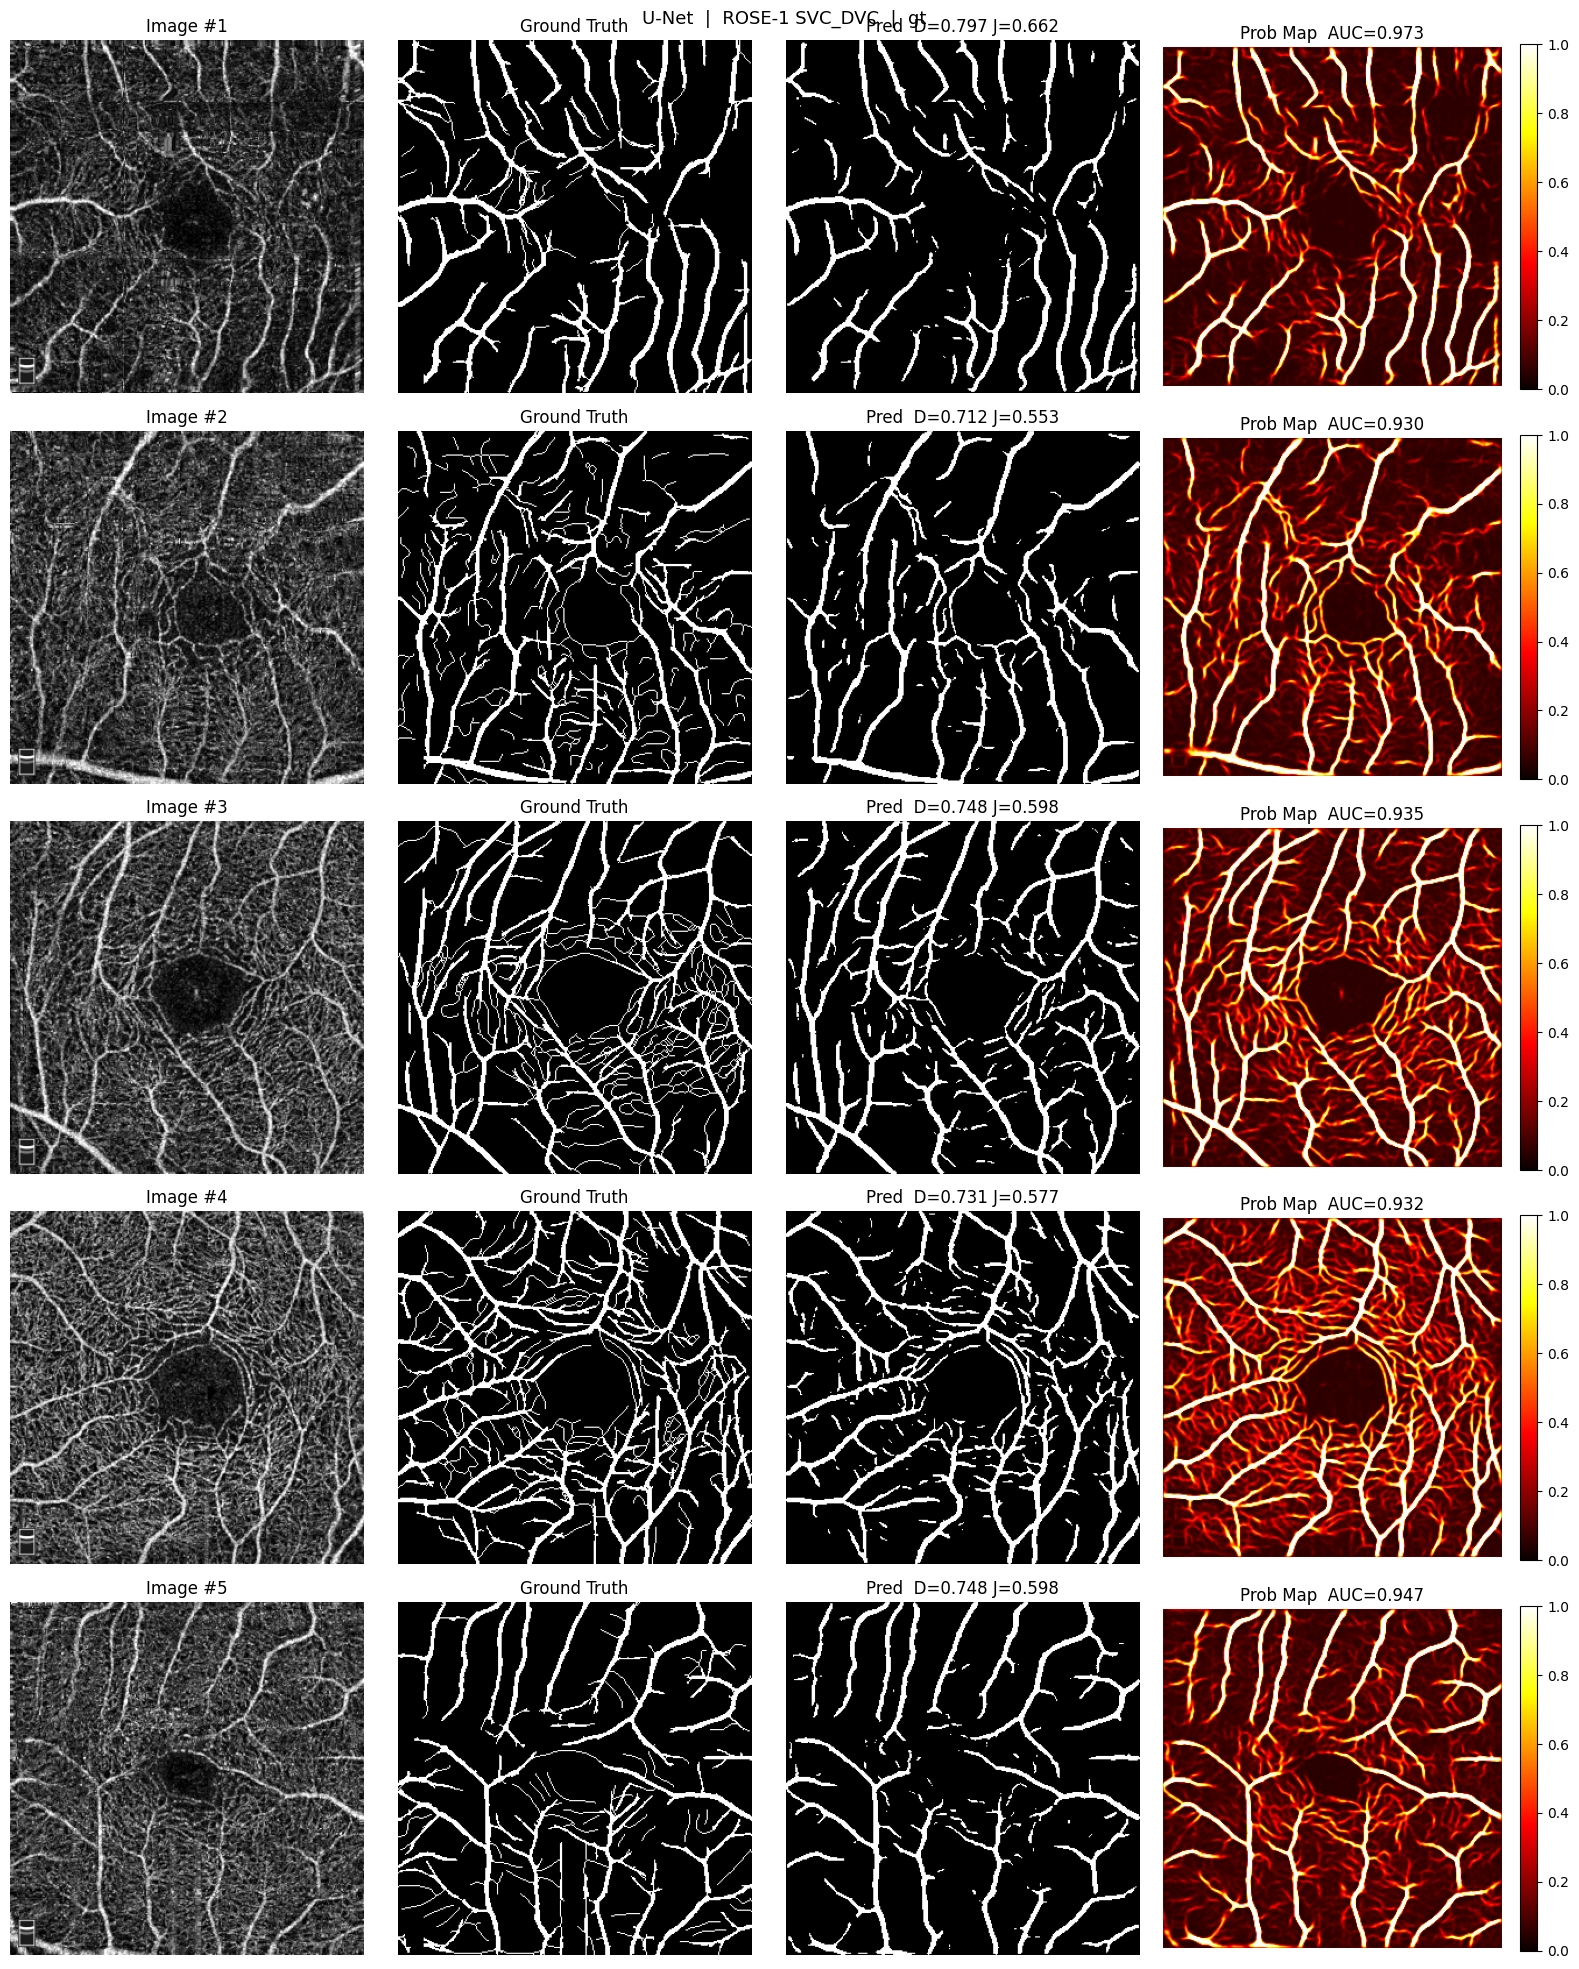

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

model = UNet().to(device)
model.load_state_dict(torch.load(os.path.join(SAVE_DIR, 'best_overall.pth'),
                                  map_location=device))
model.eval()

NUM_VIS = min(5, len(test_ds))
fig, axes = plt.subplots(NUM_VIS, 4, figsize=(16, 4*NUM_VIS))
if NUM_VIS == 1: axes = axes[np.newaxis]
fig.suptitle(f'U-Net  |  ROSE-1 {CATEGORY}  |  {GT_TYPE}', fontsize=13)

with torch.no_grad():
    for i in range(NUM_VIS):
        img, mask = test_ds[i]
        prob = model(img.unsqueeze(0).to(device))[0,0].cpu().numpy()
        pred = (prob > 0.5).astype(float)
        img_np  = img[0].numpy()
        mask_np = mask[0].numpy()
        m = compute_metrics(pred, mask_np, prob)

        axes[i,0].imshow(img_np,  cmap='gray'); axes[i,0].set_title(f'Image #{i+1}'); axes[i,0].axis('off')
        axes[i,1].imshow(mask_np, cmap='gray'); axes[i,1].set_title('Ground Truth');  axes[i,1].axis('off')
        axes[i,2].imshow(pred,    cmap='gray')
        axes[i,2].set_title(f'Pred  D={m["dice"]:.3f} J={m["jaccard"]:.3f}')
        axes[i,2].axis('off')
        im = axes[i,3].imshow(prob, cmap='hot', vmin=0, vmax=1)
        axes[i,3].set_title(f'Prob Map  AUC={m["auc"]:.3f}'); axes[i,3].axis('off')
        plt.colorbar(im, ax=axes[i,3], fraction=0.046)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'predictions.png'), dpi=150, bbox_inches='tight')
plt.show()


## 8. Training Curves

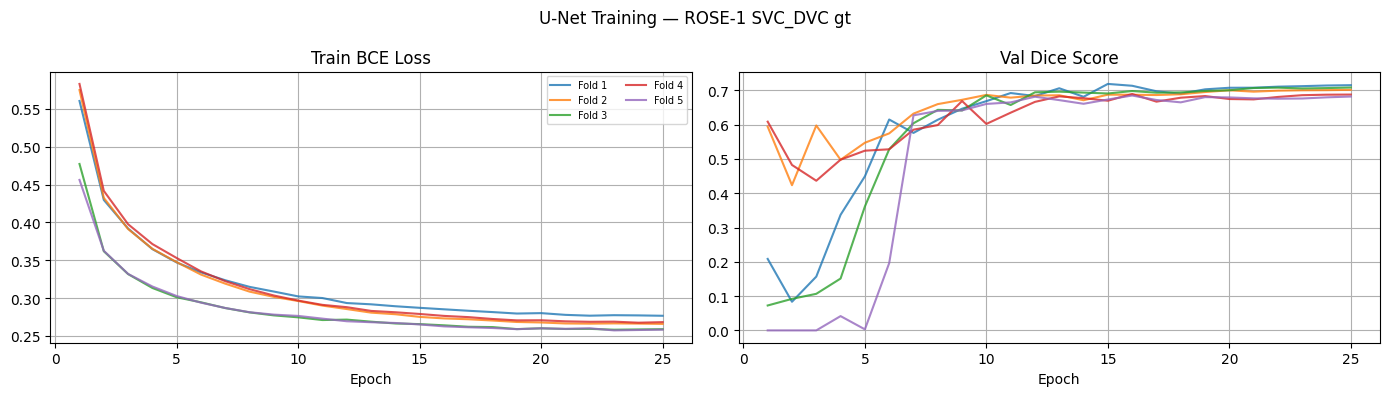

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
colors = plt.cm.tab10.colors

for i, h in enumerate(fold_histories):
    eps = range(1, len(h['train_loss'])+1)
    c = colors[i % 10]
    axes[0].plot(eps, h['train_loss'], color=c, lw=1.5, alpha=0.8, label=f'Fold {i+1}')
    axes[1].plot(eps, h['val_dice'],   color=c, lw=1.5, alpha=0.8)

axes[0].set_title('Train BCE Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(fontsize=7, ncol=2); axes[0].grid(True)
axes[1].set_title('Val Dice Score'); axes[1].set_xlabel('Epoch'); axes[1].grid(True)

plt.suptitle(f'U-Net Training — ROSE-1 {CATEGORY} {GT_TYPE}', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()


## 9. Confusion Matrix & ROC Curve

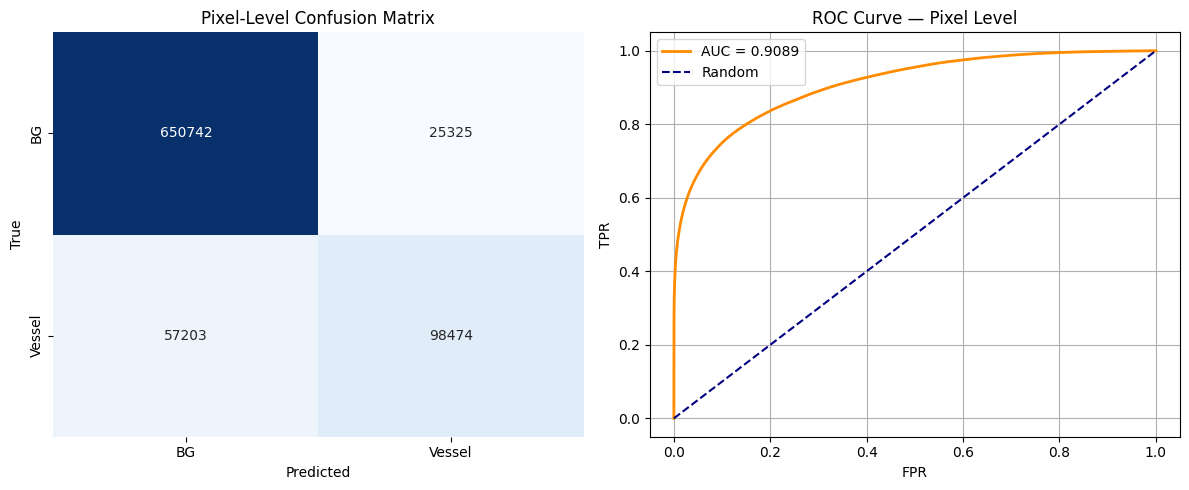

ROC AUC: 0.9089


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc as sk_auc
import numpy as np

all_pred, all_gt, all_prob = [], [], []
model.eval()
with torch.no_grad():
    for img, mask in test_ds:
        prob = model(img.unsqueeze(0).to(device))[0,0].cpu().numpy()
        pred = (prob > 0.5).astype(int)
        all_pred.append(pred.flatten())
        all_gt.append(mask[0].numpy().flatten().astype(int))
        all_prob.append(prob.flatten())

preds_flat = np.concatenate(all_pred)
gt_flat    = np.concatenate(all_gt)
probs_flat = np.concatenate(all_prob)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(gt_flat, preds_flat)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['BG','Vessel'], yticklabels=['BG','Vessel'], cbar=False)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].set_title('Pixel-Level Confusion Matrix')

fpr, tpr, _ = roc_curve(gt_flat, probs_flat)
roc_auc = sk_auc(fpr, tpr)
axes[1].plot(fpr, tpr, 'darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
axes[1].plot([0,1],[0,1],'navy',lw=1.5,ls='--',label='Random')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve — Pixel Level')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'cm_roc.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'ROC AUC: {roc_auc:.4f}')
